# Minimal Dynamic-DeepHit (NASA demo)

This notebook mirrors the minimal Dynamic-DeepHit baseline implemented in `baselines/ddh_minimal.py` and runs it end-to-end on the NASA dataset. Feel free to tweak hyperparameters or swap datasets directly in the cells below.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
import optax
import yaml

from dataclasses import dataclass
from typing import Any, Dict

from utils import TimesDataGenerator, concordance_index, get_data, train_test_split


In [2]:
@dataclass
class DDHConfig:
    dataset_name: str
    dataset_kwargs: Dict[str, Any]
    batch_size: int = 64
    learning_rate: float = 1e-3
    num_epochs: int = 50
    hidden_size: int = 64
    test_size: float = 0.2
    axis: int = 2
    seed: int = 0
    log_interval: int = 10
    landmark: bool = False
    ranking_weight: float = 0.1
    ranking_sigma: float = 1

    @classmethod
    def from_yaml(cls, path: str | Path) -> "DDHConfig":
        with open(path, "r") as fh:
            raw = yaml.safe_load(fh)

        if "dataset_kwargs" not in raw:
            raise ValueError("Config file must define 'dataset_kwargs'.")

        arch_kwargs = raw.get("arch", {}).get("arch_kwargs", {})
        hidden_size = raw.get("ddh_hidden_size", arch_kwargs.get("hidden_size", cls.hidden_size))
        ranking_weight = raw.get("ddh_ranking_weight", cls.ranking_weight)
        ranking_sigma = raw.get("ddh_ranking_sigma", cls.ranking_sigma)

        return cls(
            dataset_name=raw["dataset_name"],
            dataset_kwargs=raw["dataset_kwargs"],
            batch_size=raw.get("batch_size", cls.batch_size),
            learning_rate=raw.get("learning_rate", cls.learning_rate),
            num_epochs=raw.get("num_epochs", cls.num_epochs),
            hidden_size=hidden_size,
            test_size=raw.get("test_size", cls.test_size),
            axis=raw.get("axis", cls.axis),
            seed=raw.get("seed", cls.seed),
            log_interval=raw.get("log_interval", cls.log_interval),
            landmark=raw.get("landmark", cls.landmark),
            ranking_weight=ranking_weight,
            ranking_sigma=ranking_sigma,
        )


In [3]:
from functools import partial

def brier_score_numpy(h, surv, ts, cs):
    cs = cs.astype(np.bool_)
    h = min(h, surv.shape[1])
    ws = kaplan_meier_numpy(ts - ~cs, ~cs)

    ts_idx = np.clip(ts, 1, surv.shape[1])
    mask_event = np.where((ts <= h) & ~cs, 1, 0)
    comp1 = (1 / ws[ts_idx - 1]) * (0.0 - surv[:, h - 1]) ** 2 * mask_event
    comp1 = np.where(np.isinf(comp1), 0, comp1)
    comp1 = np.where(np.isnan(comp1), 0, comp1)

    mask_cens = np.where((ts > h) | ((ts == h) & cs), 1, 0)
    comp2 = (1 / ws[h - 1]) * (1.0 - surv[:, h - 1]) ** 2 * mask_cens
    comp2 = np.where(np.isinf(comp2), 0, comp2)
    comp2 = np.where(np.isnan(comp2), 0, comp2)

    return float(np.sum(comp1) + np.sum(comp2))


def kaplan_meier_numpy(ts, cs):
    cs = cs.astype(np.bool_)
    steps = np.arange(0, np.max(ts) + 1)
    at_risk = np.sum(ts[:, np.newaxis] >= steps, axis=0)
    events = np.sum(ts[~cs, np.newaxis] == steps, axis=0)
    return np.cumprod(1 - events / at_risk)


def integrated_brier_score_numpy(surv, ts, cs):
    t_max = int(np.max(ts))
    if t_max == 0:
        return 0.0
    scorer = partial(brier_score_numpy, surv=surv, ts=ts, cs=cs)
    hs = np.arange(1, t_max + 1)
    scores = np.array([scorer(h) for h in hs])
    return float(np.sum(scores) / (t_max * len(ts)))


In [4]:
def build_model(hidden_size: int, horizon: int) -> hk.Transformed:
    def forward(inputs: jnp.ndarray) -> jnp.ndarray:
        batch_size = inputs.shape[0]
        x = hk.Linear(hidden_size)(inputs)
        x = jax.nn.relu(x)
        x = jnp.swapaxes(x, 0, 1)

        core = hk.GRU(hidden_size)
        initial_state = core.initial_state(batch_size)
        outputs, _ = hk.dynamic_unroll(core, x, initial_state)
        outputs = jnp.swapaxes(outputs, 0, 1)

        logits = hk.Linear(horizon)(outputs)
        return logits

    return hk.without_apply_rng(hk.transform(forward))


def hazard_loss_from_logits(logits, targets, mask):
    bce = optax.sigmoid_binary_cross_entropy(logits, targets)
    weights = mask.astype(jnp.float32)
    normalizer = jnp.maximum(jnp.sum(weights), 1.0)
    return jnp.sum(bce * weights) / normalizer


def _hazard_path_from_logits(logits, axis):
    hazards = jax.nn.sigmoid(logits)
    if axis == 2:
        return hazards[:, 0, :]
    if axis == 1:
        return hazards
    raise ValueError(f'Unsupported axis value: {axis}')


def _survival_and_cdf_from_logits(logits, axis):
    hazard_path = _hazard_path_from_logits(logits, axis)

    def step(prev_surv, h_t):
        event_prob = prev_surv * h_t
        new_surv = prev_surv * (1.0 - h_t)
        return new_surv, (new_surv, event_prob)

    init_surv = jnp.ones(hazard_path.shape[0], dtype=hazard_path.dtype)
    _, (surv_seq, event_seq) = jax.lax.scan(step, init_surv, hazard_path.T)

    surv_seq = jnp.concatenate([jnp.ones((1, hazard_path.shape[0])), surv_seq], axis=0)
    surv_curve = surv_seq.T
    cdf = jnp.cumsum(event_seq.T, axis=1)
    return surv_curve, cdf


def survival_curve_from_logits(logits: jnp.ndarray, axis: int) -> jnp.ndarray:
    surv_curve, _ = _survival_and_cdf_from_logits(logits, axis)
    return surv_curve


def ranking_loss_from_logits(logits, ts, cs, axis, sigma):
    _, cdf = _survival_and_cdf_from_logits(logits, axis)

    ts = jnp.asarray(ts, dtype=jnp.int32)
    cs = jnp.asarray(cs)
    events = (~cs.astype(jnp.bool_)).astype(jnp.float32)

    if cdf.shape[1] == 0:
        return jnp.array(0.0, dtype=jnp.float32)

    ts_clipped = jnp.clip(ts, 1, cdf.shape[1])
    time_indices = ts_clipped - 1

    def gather_for_time(t_idx):
        return cdf[:, t_idx]

    cdf_at_times = jax.vmap(gather_for_time)(time_indices)
    cdf_i = jnp.take_along_axis(cdf, time_indices[:, None], axis=1).squeeze(axis=1)

    diff = cdf_i[:, None] - cdf_at_times
    rank_matrix = jnp.exp(-diff / sigma)

    time_mask = ts[None, :] > ts[:, None]
    valid = (events[:, None] == 1.0) & time_mask
    valid = valid.astype(jnp.float32)

    denom = jnp.maximum(jnp.sum(valid), 1.0)
    loss = jnp.sum(rank_matrix * valid) / denom
    return loss


def median_time_from_survival(surv: jnp.ndarray) -> jnp.ndarray:
    def median_idx(curve: jnp.ndarray) -> jnp.ndarray:
        threshold = 0.5
        crosses = curve <= threshold
        has_cross = jnp.any(crosses)
        idx = jnp.where(has_cross, jnp.argmax(crosses), curve.shape[0] - 1)
        return idx.astype(jnp.float32)

    return jax.vmap(median_idx)(surv)


def train(config: DDHConfig):
    seqs, ts, cs, target, h_ws, mask = get_data(
        config.dataset_name,
        config.landmark,
        True,
        config.dataset_kwargs,
    )

    seqs = seqs.astype(np.float32)
    target = target.astype(np.float32)
    mask = mask.astype(np.float32)
    h_ws = h_ws.astype(np.float32)

    (X_train, X_test, y_train, y_test, hws_train, hws_test,
     m_train, m_test, ts_train, ts_test, cs_train, cs_test) = train_test_split(
        seqs,
        target,
        h_ws,
        mask,
        ts,
        cs,
        seed=config.seed,
        test_size=config.test_size,
    )

    train_gen = TimesDataGenerator(
        X=X_train,
        ts=ts_train,
        cs=cs_train,
        y=y_train,
        mask=m_train,
        h_ws=hws_train,
        batch_size=config.batch_size,
        rng=np.random.default_rng(config.seed),
    )

    horizon = config.dataset_kwargs.get("horizon", seqs.shape[1])
    model = build_model(config.hidden_size, horizon)

    key = jax.random.PRNGKey(config.seed)
    sample = jnp.asarray(X_train[:1])
    params = model.init(key, sample)

    optimizer = optax.adam(config.learning_rate)
    opt_state = optimizer.init(params)

    def loss_fn(model_params, batch_x, batch_ts, batch_cs, batch_y, batch_m):
        logits = model.apply(model_params, batch_x)
        h_loss = hazard_loss_from_logits(logits, batch_y, batch_m)
        r_loss = ranking_loss_from_logits(
            logits,
            batch_ts,
            batch_cs,
            axis=config.axis,
            sigma=config.ranking_sigma,
        )
        total = h_loss + config.ranking_weight * r_loss
        return total, (h_loss, r_loss)

    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    total_history = []
    hazard_history = []
    ranking_history = []
    for epoch in range(1, config.num_epochs + 1):
        epoch_total = []
        epoch_hazard = []
        epoch_ranking = []
        for batch in train_gen:
            batch_x, batch_ts, batch_cs, batch_y, batch_m, _ = batch
            batch_x = jnp.asarray(batch_x)
            batch_ts = jnp.asarray(batch_ts)
            batch_cs = jnp.asarray(batch_cs)
            batch_y = jnp.asarray(batch_y)
            batch_m = jnp.asarray(batch_m)

            (total_loss, (hazard_loss, ranking_loss)), grads = grad_fn(
                params,
                batch_x,
                batch_ts,
                batch_cs,
                batch_y,
                batch_m,
            )
            updates, opt_state = optimizer.update(grads, opt_state, params)
            params = optax.apply_updates(params, updates)
            epoch_total.append(total_loss)
            epoch_hazard.append(hazard_loss)
            epoch_ranking.append(ranking_loss)

        train_gen.reset()
        mean_total = float(jnp.mean(jnp.stack(epoch_total)))
        mean_hazard = float(jnp.mean(jnp.stack(epoch_hazard)))
        mean_ranking = float(jnp.mean(jnp.stack(epoch_ranking)))
        total_history.append(mean_total)
        hazard_history.append(mean_hazard)
        ranking_history.append(mean_ranking)

        if epoch % config.log_interval == 0 or epoch == 1 or epoch == config.num_epochs:
            print(
                f"Epoch {epoch:03d} | total: {mean_total:.4f} | "
                f"hazard: {mean_hazard:.4f} | ranking: {mean_ranking:.4f}"
            )

    test_x = jnp.asarray(X_test)
    test_y = jnp.asarray(y_test)
    test_m = jnp.asarray(m_test)
    logits = model.apply(params, test_x)
    test_hazard_loss = float(hazard_loss_from_logits(logits, test_y, test_m))
    test_ranking_loss = float(
        ranking_loss_from_logits(
            logits,
            jnp.asarray(ts_test),
            jnp.asarray(cs_test),
            axis=config.axis,
            sigma=config.ranking_sigma,
        )
    )

    surv = survival_curve_from_logits(logits, axis=config.axis)
    med_times = np.asarray(median_time_from_survival(surv))
    ci = float(concordance_index(med_times, ts_test, cs_test))
    ibs = integrated_brier_score_numpy(
        np.asarray(surv[:, 1:]),
        np.asarray(ts_test),
        np.asarray(cs_test),
    )

    return {
        "params": params,
        "opt_state": opt_state,
        "total_history": total_history,
        "hazard_history": hazard_history,
        "ranking_history": ranking_history,
        "test_hazard_loss": test_hazard_loss,
        "test_ranking_loss": test_ranking_loss,
        "ci": ci,
        "ibs": ibs,
    }


In [9]:
config_path = Path("../configs/config_pbc.yaml")
config = DDHConfig.from_yaml(config_path)
config.num_epochs = 20
config.batch_size = 32
config.log_interval = 1
config.seed = 0
config.test_size = 0.2

config


DDHConfig(dataset_name='pbc2', dataset_kwargs={'horizon': 16, 'data_path': '/Users/mariana/Documents/mariana_lts4mac_backup/SurvanData/small/pbc-seqs.pkl'}, batch_size=32, learning_rate=0.1, num_epochs=20, hidden_size=64, test_size=0.2, axis=2, seed=0, log_interval=1, landmark=True, ranking_weight=0.1, ranking_sigma=1)

In [10]:
results = train(config)
results["test_hazard_loss"], results["test_ranking_loss"], results["ci"], results["ibs"]


Epoch 001 | total: 0.2837 | hazard: 0.1844 | ranking: 0.9928
Epoch 002 | total: 0.1799 | hazard: 0.0860 | ranking: 0.9381
Epoch 003 | total: 0.1548 | hazard: 0.0748 | ranking: 0.7993
Epoch 004 | total: 0.1426 | hazard: 0.0665 | ranking: 0.7607
Epoch 005 | total: 0.1391 | hazard: 0.0619 | ranking: 0.7716
Epoch 006 | total: 0.1410 | hazard: 0.0615 | ranking: 0.7949
Epoch 007 | total: 0.1347 | hazard: 0.0605 | ranking: 0.7425
Epoch 008 | total: 0.1361 | hazard: 0.0582 | ranking: 0.7793
Epoch 009 | total: 0.1382 | hazard: 0.0588 | ranking: 0.7939
Epoch 010 | total: 0.1349 | hazard: 0.0592 | ranking: 0.7564
Epoch 011 | total: 0.1286 | hazard: 0.0553 | ranking: 0.7332
Epoch 012 | total: 0.1322 | hazard: 0.0577 | ranking: 0.7457
Epoch 013 | total: 0.1308 | hazard: 0.0575 | ranking: 0.7330
Epoch 014 | total: 0.1267 | hazard: 0.0555 | ranking: 0.7116
Epoch 015 | total: 0.1317 | hazard: 0.0587 | ranking: 0.7307
Epoch 016 | total: 0.1335 | hazard: 0.0580 | ranking: 0.7552
Epoch 017 | total: 0.138

(0.045830827206373215,
 0.7466979622840881,
 0.7843719090009891,
 0.16568768567231604)

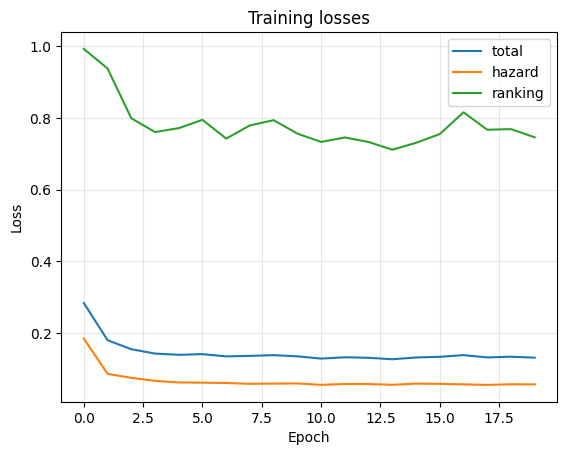

In [11]:
import matplotlib.pyplot as plt

plt.plot(results['total_history'], label='total')
plt.plot(results['hazard_history'], label='hazard')
plt.plot(results['ranking_history'], label='ranking')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training losses')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [12]:
# Recreate the evaluation split to inspect predictions on the PBC dataset
seqs, ts, cs, target, h_ws, mask = get_data(
    config.dataset_name,
    config.landmark,
    True,
    config.dataset_kwargs,
)

seqs = seqs.astype(np.float32)
target = target.astype(np.float32)
mask = mask.astype(np.float32)
h_ws = h_ws.astype(np.float32)

(X_train, X_test, y_train, y_test, hws_train, hws_test,
 m_train, m_test, ts_train, ts_test, cs_train, cs_test) = train_test_split(
    seqs,
    target,
    h_ws,
    mask,
    ts,
    cs,
    seed=config.seed,
    test_size=config.test_size,
)

model = build_model(config.hidden_size, config.dataset_kwargs.get('horizon', seqs.shape[1]))
test_x = jnp.asarray(X_test)
logits = model.apply(results['params'], test_x)
surv = survival_curve_from_logits(logits, axis=config.axis)
median_pred = np.asarray(median_time_from_survival(surv))
surv_np = np.asarray(surv)

ci_raw = concordance_index(median_pred, ts_test, cs_test)
ci_neg = concordance_index(-median_pred, ts_test, cs_test)
pearson = float(np.corrcoef(median_pred, ts_test)[0, 1])
unique_medians = np.unique(median_pred).size

ci_raw, ci_neg, pearson, unique_medians


(0.7843719090009891, 0.21562809099901087, 0.40948354433067496, 3)

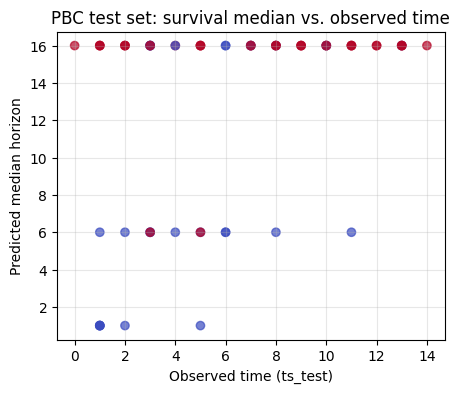

In [13]:
# Quick diagnostic plot: predicted median horizon vs. observed time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(ts_test, median_pred, c=cs_test.astype(int), cmap='coolwarm', alpha=0.7)
ax.set_xlabel('Observed time (ts_test)')
ax.set_ylabel('Predicted median horizon')
ax.set_title('PBC test set: survival median vs. observed time')
ax.grid(True, alpha=0.3)
plt.show()


In [14]:
# Inspect a few survival curves to see how sharp they are
sample_ids = np.random.default_rng(config.seed).choice(len(surv_np), size=min(5, len(surv_np)), replace=False)
for idx in sample_ids:
    print(f'Sample {idx} | ts={ts_test[idx]} | censored={cs_test[idx]}')
    print(np.round(surv_np[idx], 3))
    print('-' * 40)


Sample 37 | ts=10 | censored=False
[1.    0.988 0.977 0.963 0.956 0.95  0.935 0.914 0.897 0.881 0.866 0.861
 0.856 0.855 0.855 0.855 0.855]
----------------------------------------
Sample 30 | ts=1 | censored=False
[1.    0.066 0.042 0.03  0.028 0.027 0.026 0.026 0.026 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025]
----------------------------------------
Sample 16 | ts=7 | censored=True
[1.    0.988 0.977 0.963 0.956 0.95  0.935 0.914 0.897 0.881 0.866 0.861
 0.856 0.855 0.855 0.855 0.855]
----------------------------------------
Sample 19 | ts=2 | censored=True
[1.    0.988 0.977 0.963 0.956 0.95  0.935 0.914 0.897 0.881 0.866 0.861
 0.856 0.855 0.855 0.855 0.855]
----------------------------------------
Sample 49 | ts=1 | censored=False
[1.    0.066 0.042 0.03  0.028 0.027 0.026 0.026 0.026 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025]
----------------------------------------


**Diagnostic Interpretation**
- `ci_raw` is the c-index using the current score definition; `ci_neg` flips the sign to test orientation.
- `pearson` reports simple correlation between predicted medians and observed horizons.
- `unique_medians` checks for collapse (very low values suggest the network predicts nearly identical curves).
- Use the scatter plot and survival snapshots above to gauge whether the model differentiates subjects.
